In [1]:
import ast

s = '''
match x:
    case Point.Var(P(), "y"):
        pass

'''

print(ast.dump(ast.parse(s), indent=2))

Module(
  body=[
    Match(
      subject=Name(id='x', ctx=Load()),
      cases=[
        match_case(
          pattern=MatchClass(
            cls=Attribute(
              value=Name(id='Point', ctx=Load()),
              attr='Var',
              ctx=Load()),
            patterns=[
              MatchClass(
                cls=Name(id='P', ctx=Load())),
              MatchValue(
                value=Constant(value='y'))]),
          body=[
            Pass()])])])


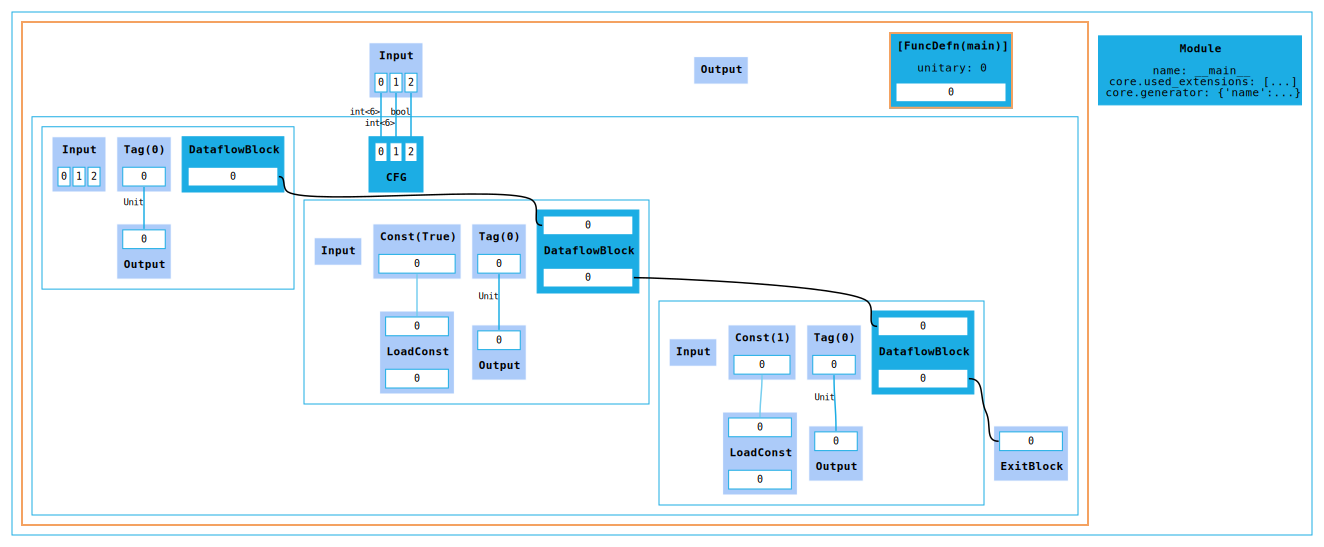

In [14]:
from guppylang import guppy
from guppylang.std.quantum import qubit, h, measure, x
from hugr.hugr.render import RenderConfig

@guppy.struct
class Point:
    x: int
    y: int


@guppy
def main(a: int, q: int, c : bool) -> None:

    if True:
        # q = 22
        c = True    

    a = 1#q
    
main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=1000))

Bool


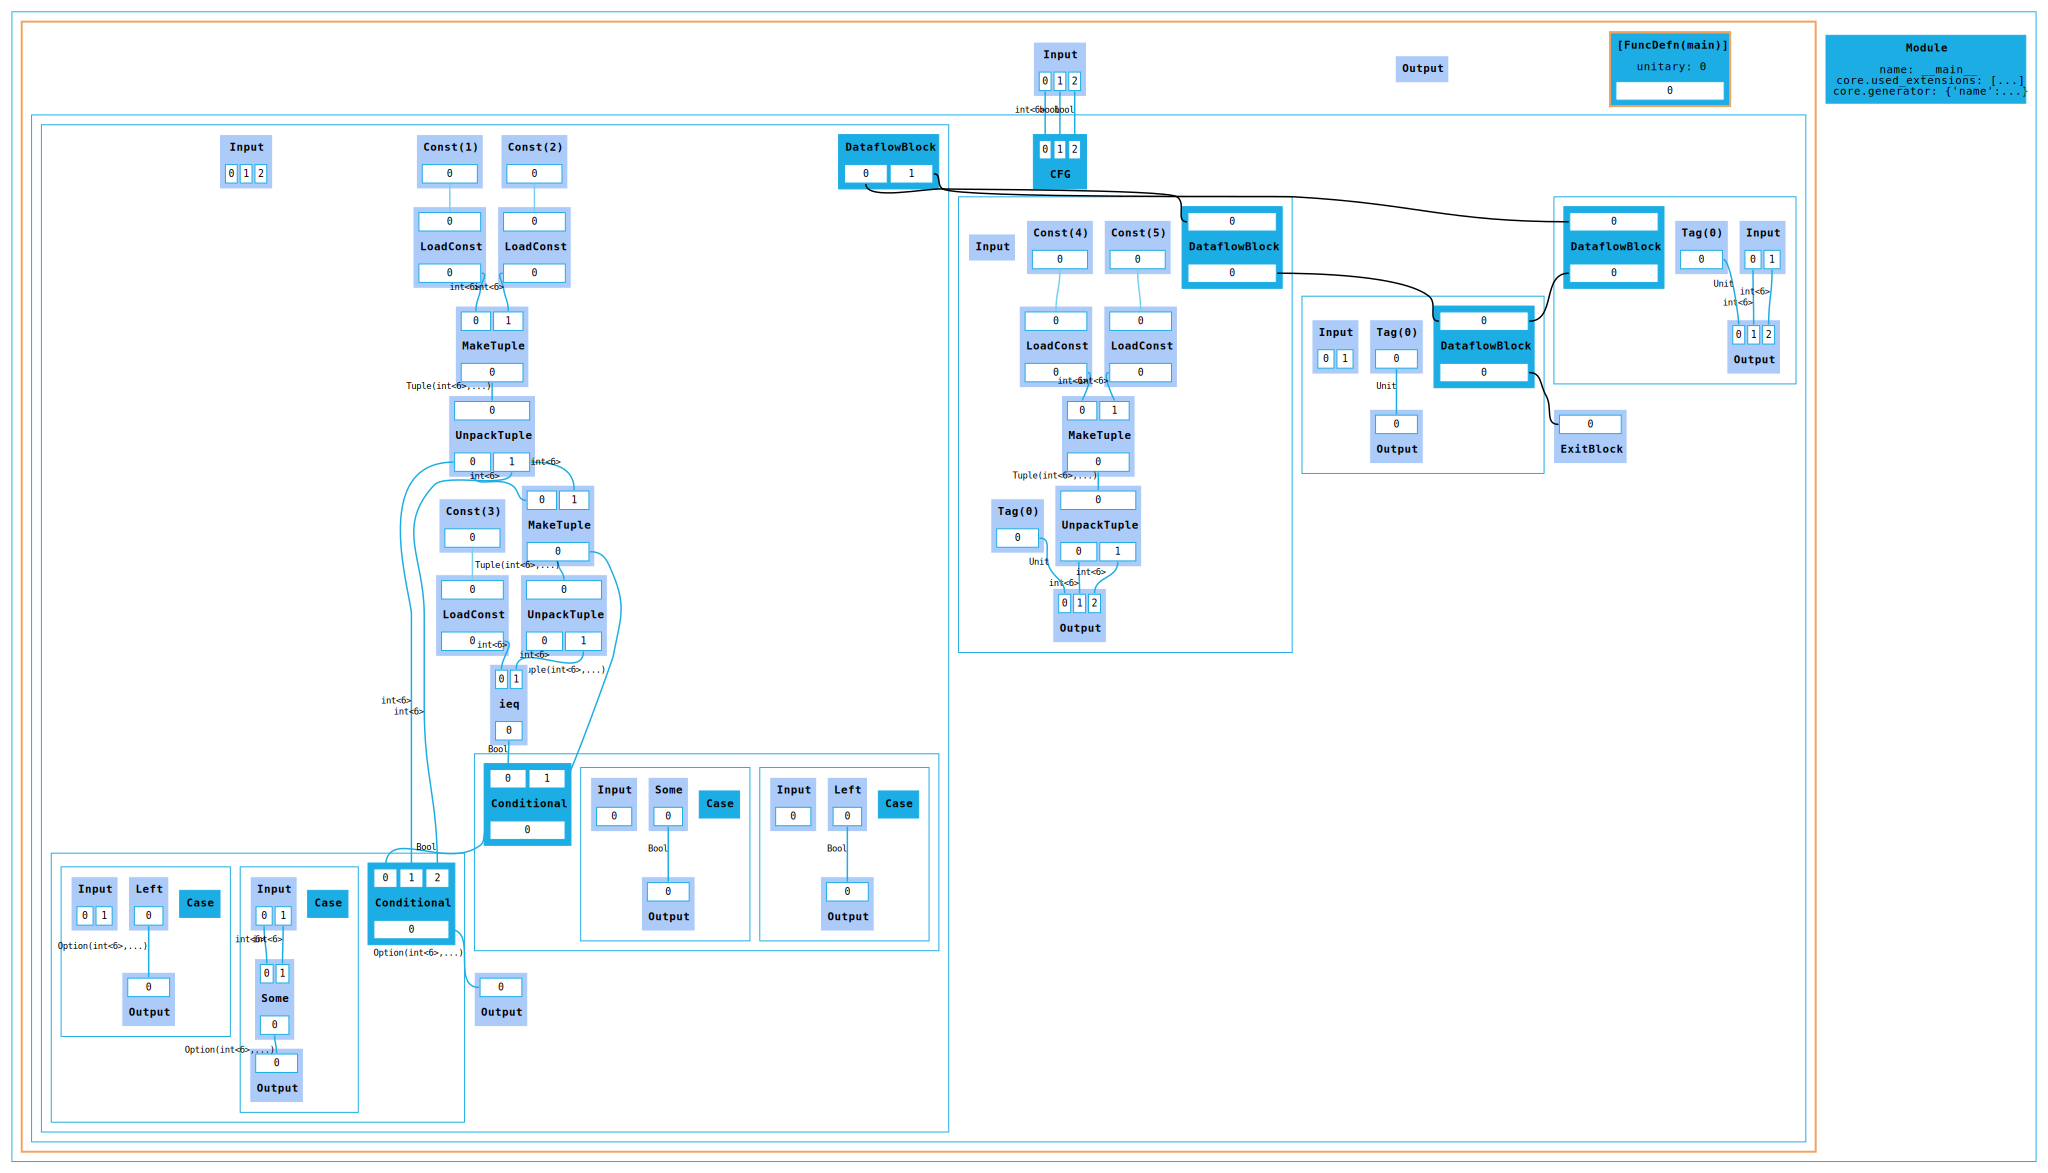

In [11]:
from guppylang import guppy
from guppylang.std.quantum import qubit
from hugr.hugr.render import RenderConfig

@guppy.struct
class Point:
    x: int
    y: int


@guppy
def main(a: int, b: bool, c : bool) -> None:
    s = Point(1, 2)
    match s:
        case Point(_, 3):
            s = Point(4, 5)
        case _:
            pass
    
    
    
    s.x
    s.y
main.compile_function().modules[0].render_dot()

boia
int
Bool


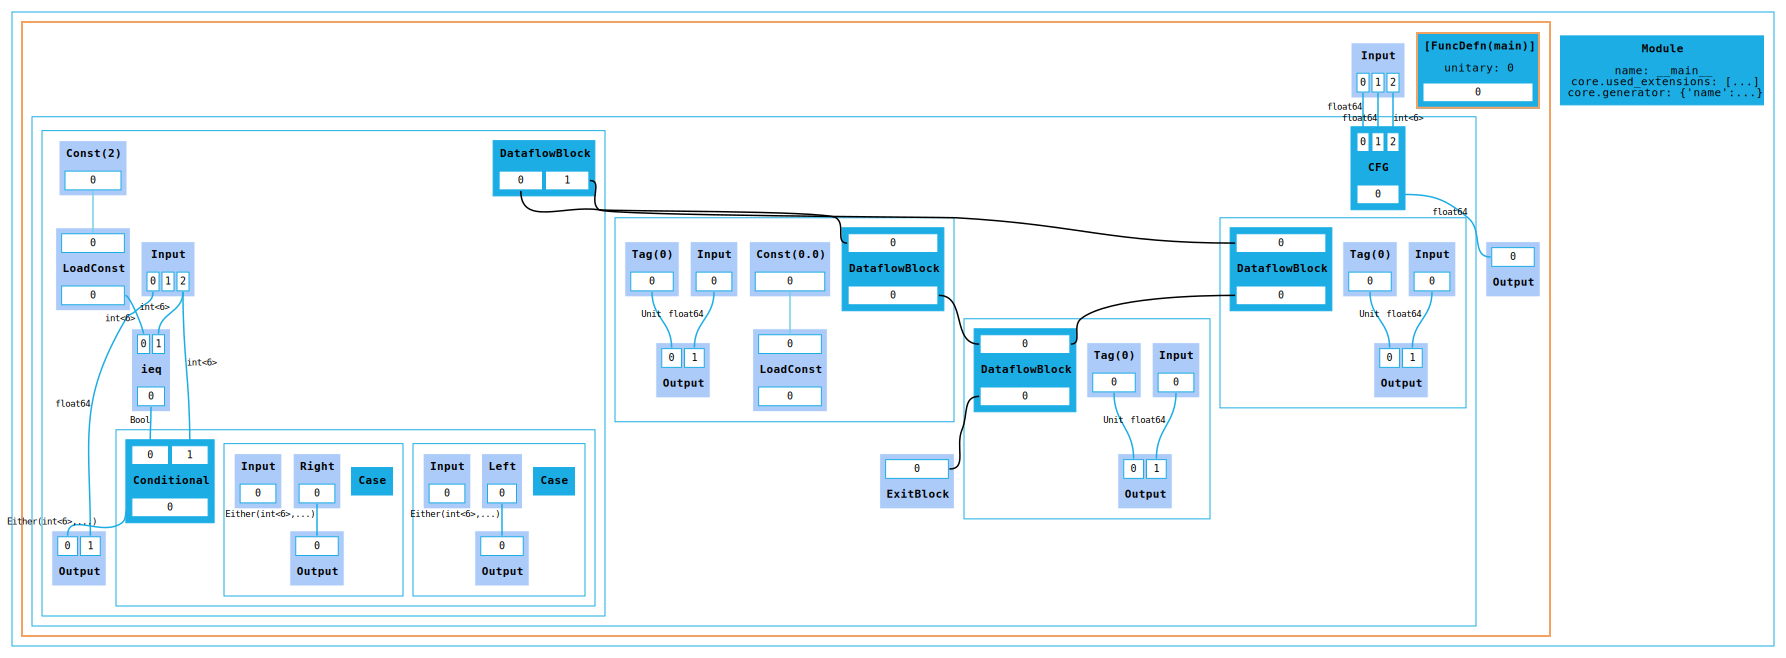

In [4]:

from guppylang import guppy

@guppy
def main(x:float, y: float, t:int) -> float:
    a = x
    match t:
        case 2:
            yr = 0.0


    return a


main.compile_function().modules[0].render_dot()

Token


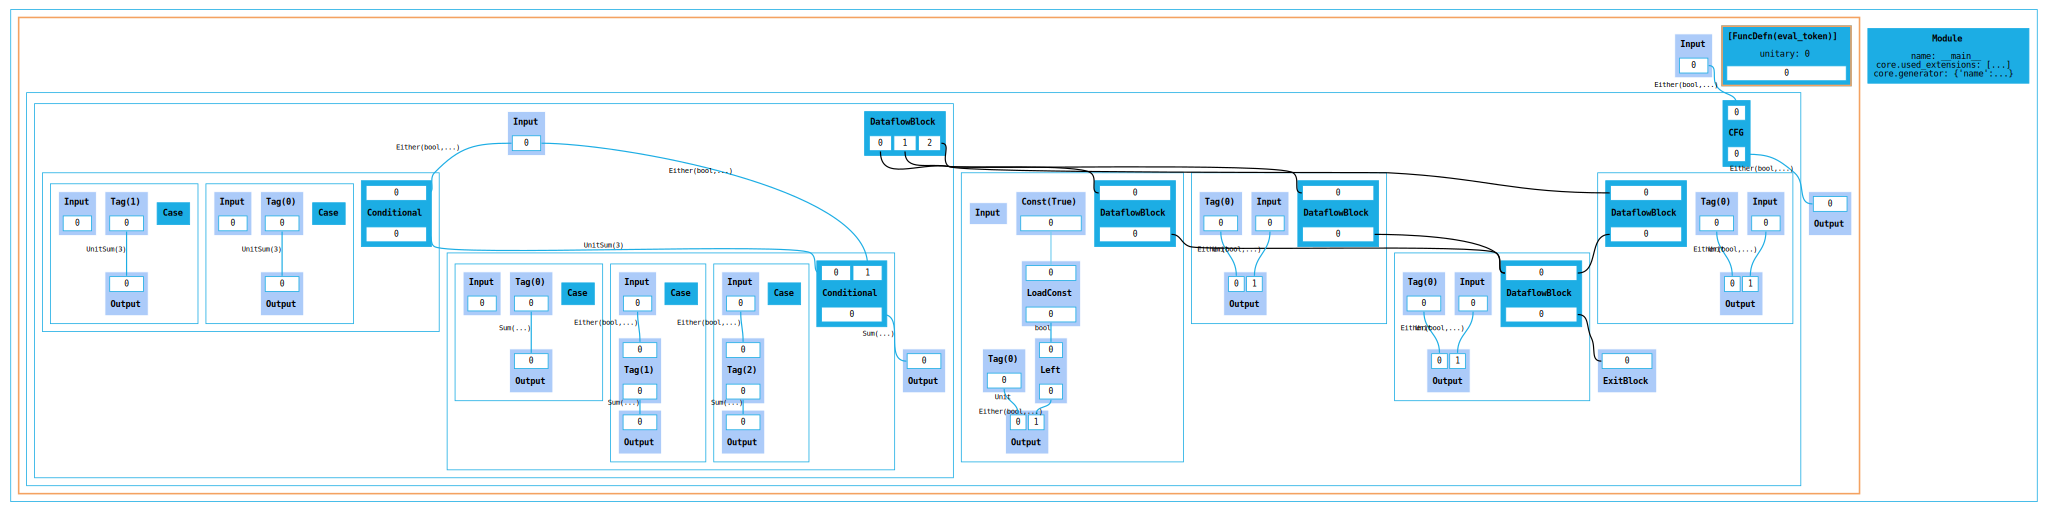

In [5]:
from guppylang import guppy
from selene_hugr_qis_compiler import check_hugr


@guppy.enum
class Token:
    # else_cond = {}
    bool_lit = {"b": bool}
    int_lit = {"n": int}
    # second_cond = {}



@guppy
def eval_token(t: Token) -> Token:
    match t:
        case Token.int_lit(_):
            t  = Token.bool_lit(True)
        case Token.bool_lit(_):
            pass
        case _:
            pass

    
    return t

h = eval_token.compile_function().modules[0]
check_hugr(h.to_bytes())
h.render_dot()


In [ ]:


# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, owned, h
from selene_hugr_qis_compiler import check_hugr



@guppy
def main() -> None:
    match 6:
        case 4:
            x = 3
        case 5:
            x = 5
        case _:
            x = 8
    


h = main.compile_function()
check_hugr(h.to_bytes())

h.modules[0].render_dot()


In [ ]:
# Example: linear variable used in multiple match arms (should error if not allowed)
from guppylang import guppy
from guppylang.std.quantum import qubit, measure, h

@guppy.struct
class Point:
    x: qubit
    y: int

@guppy
def fun() -> Point:
    return Point(qubit(), 4)

@guppy
def describe_point(point: Point)-> None:
    pass

@guppy
def main(p: Point) -> None:

    describe_point(fun())

main.check()


In [ ]:
from guppylang import guppy

@guppy.struct
class Point:
    x: int
    y: int

@guppy
def main(p: Point) -> None:
    match p:
        case Point(_, _):
            b = 1
    a = b

main.check()

In [ ]:
from guppylang import guppy
from hugr.hugr.render import RenderConfig

@guppy.enum
class Point:
    x = {"n": int}
    y = {"n": int}
    z = {"n": int}

    @guppy
    def enum(self: Point) -> None:
        pass

@guppy.struct
class Line:
    start: int
    end: int

    @guppy
    def struct(self: Line) -> None:
        pass

@guppy
def main() -> None:
    p = Point.x(1)
    p.enum()
    l = Line(2, 3)
    l.struct()

main.compile_function().modules[0].render_dot(RenderConfig(max_edge_label_length=100)).view()
    

In [ ]:
a = [1,2,3,4]

[(i, a) for i, a in enumerate(a) if a % 2 == 0]